In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

sys.path.append('..')

from pipeline_B_classic.preprocessing import preprocess
from pipeline_B_classic.segmentation import otsu_threshold
from pipeline_B_classic.postprocessing import postprocess
from pipeline_B_classic.skeletonization import skeletonize_mask
from pipeline_A_yolo.predict_tiled import (
    predict_single_image_tiled,
    tile_coordinates,
)

# ── USER: set this path ──
IMAGE_PATH = Path('70nm_R_50nm_pitch_ETD_016.tif')
# ── USER: set this path ──
WEIGHTS_PATH = Path('../outputs/weights/best.pt')

assert IMAGE_PATH.exists(), f'Image not found: {IMAGE_PATH}'
assert WEIGHTS_PATH.exists(), f'Weights not found: {WEIGHTS_PATH}'

print('✓ Setup complete')

✓ Setup complete


[ WARN:0@2.287] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34682 (0x877a) encountered


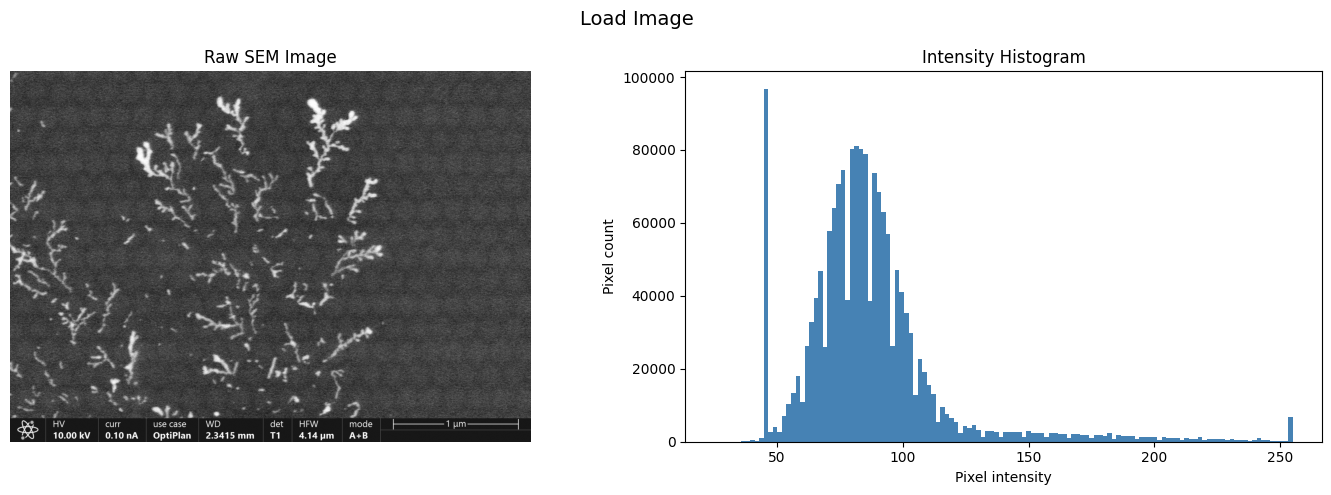

In [2]:
raw_image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
assert raw_image is not None, f'Could not read image: {IMAGE_PATH}'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(raw_image, cmap='gray')
axes[0].set_title('Raw SEM Image')
axes[0].axis('off')

axes[1].hist(raw_image.ravel(), bins=128, color='steelblue', edgecolor='none')
axes[1].set_title('Intensity Histogram')
axes[1].set_xlabel('Pixel intensity')
axes[1].set_ylabel('Pixel count')

fig.suptitle('Load Image', fontsize=14)
plt.tight_layout()
plt.show()

**Pipeline B: Preprocessing**

This step keeps the original grayscale image, stretches the intensity range, and then boosts local contrast while reducing noise.

[ WARN:0@2.600] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34682 (0x877a) encountered


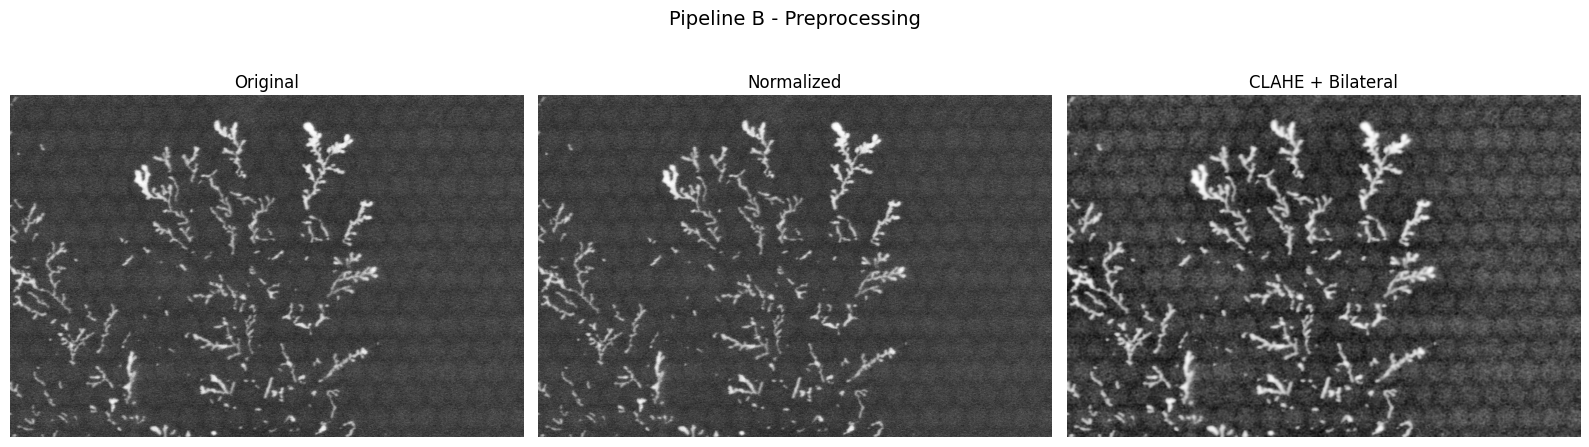

In [3]:
pre = preprocess(
    str(IMAGE_PATH),
    crop_fraction=0.065,
    clahe_clip=2.0,
    clahe_tile=8,
    bilateral_d=9,
    bilateral_sigma=75,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    (pre['raw'], 'Original'),
    (pre['normalized'], 'Normalized'),
    (pre['denoised'], 'CLAHE + Bilateral'),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

fig.suptitle('Pipeline B - Preprocessing', fontsize=14)
plt.tight_layout()
plt.show()

**Pipeline B: Segmentation**

Here Otsu thresholding turns the enhanced grayscale image into a binary dendrite mask.

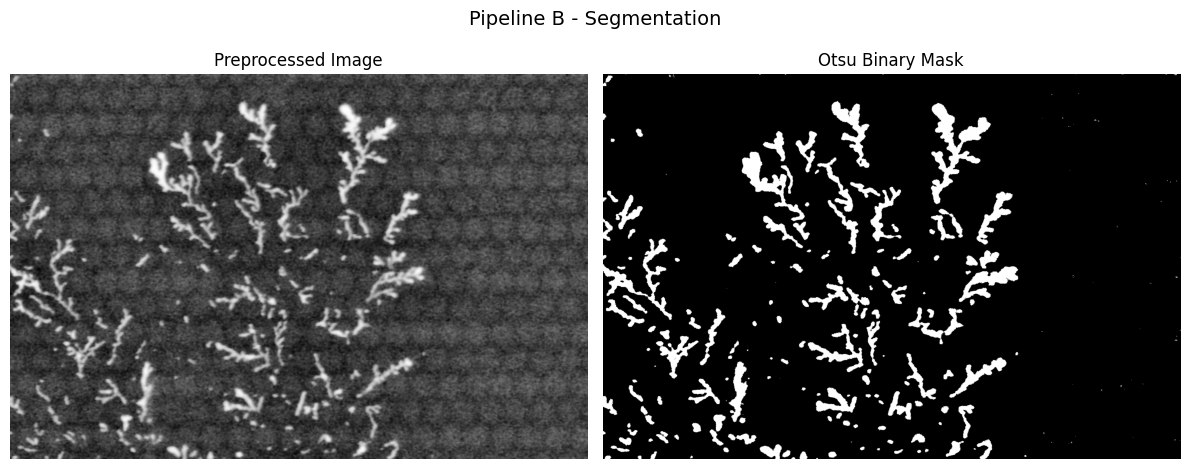

Otsu threshold value: 135.00


In [4]:
binary_mask, otsu_value = otsu_threshold(pre['denoised'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(pre['denoised'], cmap='gray')
axes[0].set_title('Preprocessed Image')
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title('Otsu Binary Mask')
axes[1].axis('off')

fig.suptitle('Pipeline B - Segmentation', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Otsu threshold value: {otsu_value:.2f}")

**Pipeline B: Postprocessing**

This stage removes small regions and applies morphology so the mask is cleaner before skeletonization.

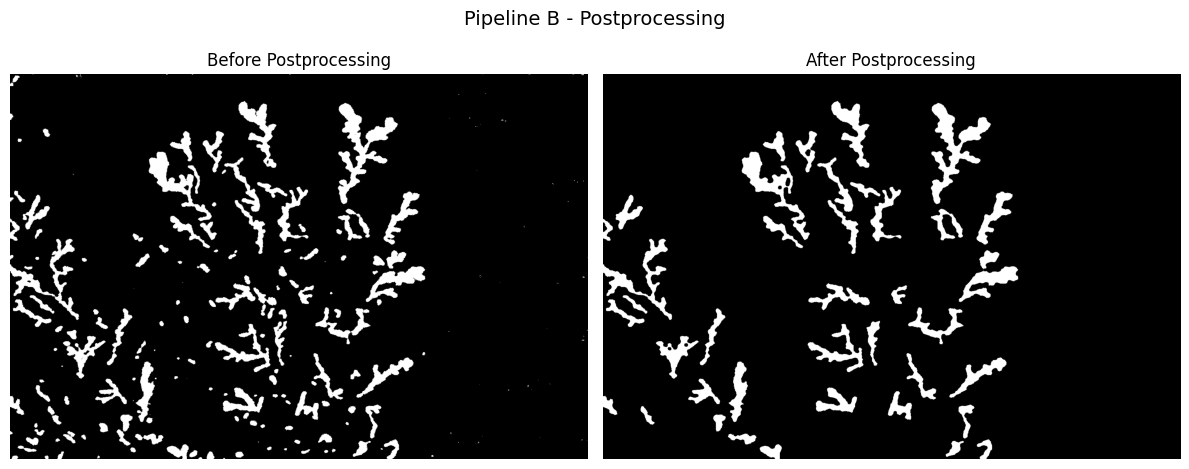

Connected components before: 243
Connected components after:  40


In [5]:
def count_components(mask: np.ndarray) -> int:
    num_labels, _, _, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    return max(0, num_labels - 1)

post = postprocess(
    binary_mask,
    min_area=600,
    closing_kernel=-1,
    erosion_size=5,
    iters=2,
    apply_shape_filter=True,
    bottom_fraction=0.16,
    bottom_min_width_fraction=0.45,
    large_area_threshold=5000,
    solidity_threshold=0.85,
    max_compact_aspect_ratio=1.8,
)

post_mask = post['filtered']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(binary_mask, cmap='gray')
axes[0].set_title('Before Postprocessing')
axes[0].axis('off')

axes[1].imshow(post_mask, cmap='gray')
axes[1].set_title('After Postprocessing')
axes[1].axis('off')

fig.suptitle('Pipeline B - Postprocessing', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Connected components before: {count_components(binary_mask)}")
print(f"Connected components after:  {count_components(post_mask)}")

**Pipeline B: Skeletonization**

The cleaned mask is reduced to a 1-pixel-wide centerline so the branch structure becomes easier to explain visually.

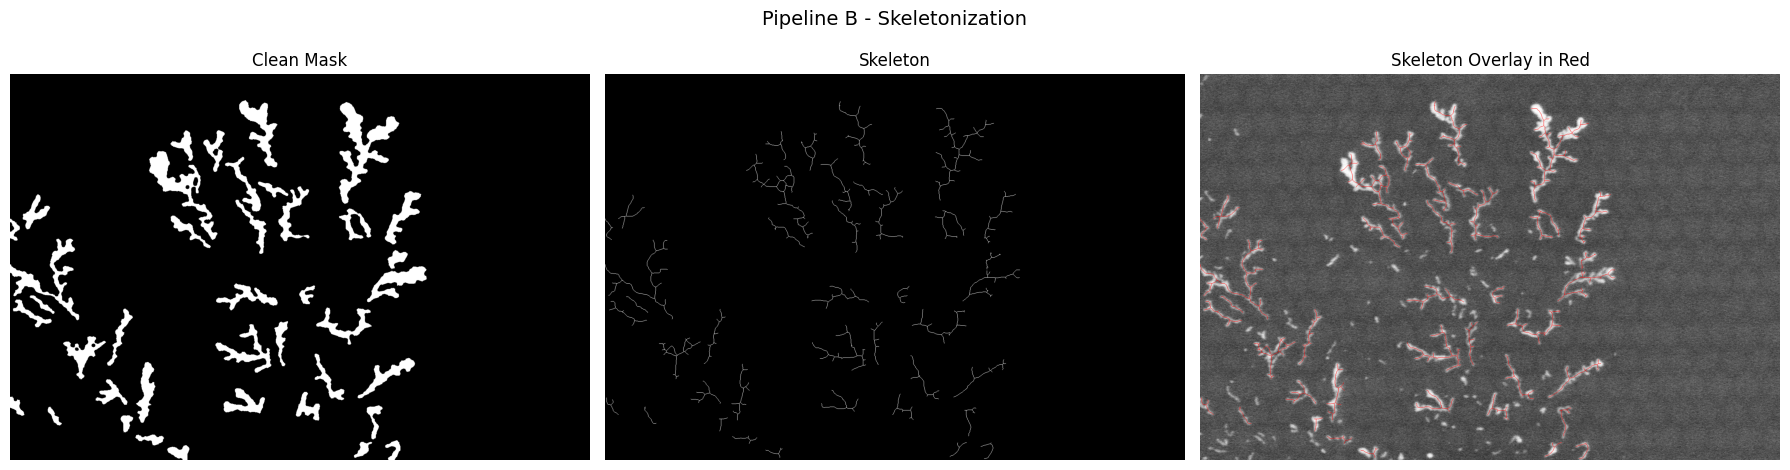

In [6]:
skel = skeletonize_mask(post_mask, peak_min_distance=5)
skeleton = skel['skeleton']

base_for_overlay = pre['raw']
if base_for_overlay.dtype != np.uint8:
    base_for_overlay = cv2.normalize(base_for_overlay, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

skeleton_overlay = cv2.cvtColor(base_for_overlay, cv2.COLOR_GRAY2RGB)
skeleton_overlay[skeleton > 0] = [255, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(post_mask, cmap='gray')
axes[0].set_title('Clean Mask')
axes[0].axis('off')

axes[1].imshow(skeleton, cmap='gray')
axes[1].set_title('Skeleton')
axes[1].axis('off')

axes[2].imshow(skeleton_overlay)
axes[2].set_title('Skeleton Overlay in Red')
axes[2].axis('off')

fig.suptitle('Pipeline B - Skeletonization', fontsize=14)
plt.tight_layout()
plt.show()

**Pipeline A: YOLO Tiled Inference**

This step runs the trained YOLO segmentation model tile by tile, then stitches the tile masks back into one full-image result.

[ WARN:0@4.482] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34682 (0x877a) encountered
[ WARN:0@5.179] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34682 (0x877a) encountered


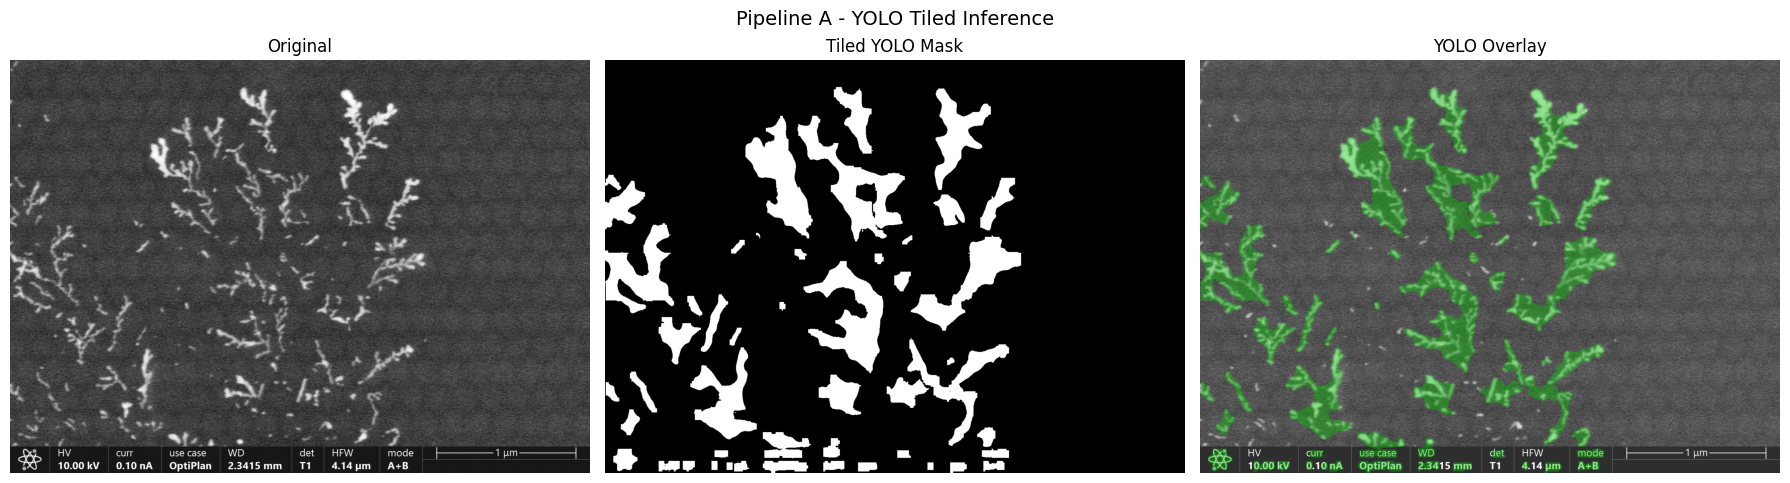

Tiled detection count: 186


In [7]:
model = YOLO(str(WEIGHTS_PATH))

def count_tiled_detections(model, image_path, conf_threshold=0.05, iou_threshold=0.45,
                           tile_size=640, overlap=0.2) -> int:
    image_bgr = cv2.imread(str(image_path))
    img_h, img_w = image_bgr.shape[:2]
    boxes = tile_coordinates(img_h, img_w, tile_size, overlap)
    total = 0

    for x0, y0, x1, y1 in boxes:
        tile = image_bgr[y0:y1, x0:x1]
        pad_h = tile_size - tile.shape[0]
        pad_w = tile_size - tile.shape[1]
        if pad_h > 0 or pad_w > 0:
            tile = cv2.copyMakeBorder(tile, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

        results = model.predict(source=tile, conf=conf_threshold, iou=iou_threshold, verbose=False)
        result = results[0]
        if result.masks is not None:
            total += len(result.masks)

    return total

yolo_mask = predict_single_image_tiled(
    model=model,
    image_path=str(IMAGE_PATH),
    conf_threshold=0.05,
    iou_threshold=0.45,
    tile_size=640,
    overlap=0.2,
    mask_threshold=0.5,
)

yolo_detection_count = count_tiled_detections(model, IMAGE_PATH)

yolo_overlay = cv2.cvtColor(raw_image, cv2.COLOR_GRAY2RGB)
yolo_overlay[yolo_mask > 0] = [0, 200, 0]
yolo_overlay = cv2.addWeighted(cv2.cvtColor(raw_image, cv2.COLOR_GRAY2RGB), 0.6, yolo_overlay, 0.4, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(raw_image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(yolo_mask, cmap='gray')
axes[1].set_title('Tiled YOLO Mask')
axes[1].axis('off')

axes[2].imshow(yolo_overlay)
axes[2].set_title('YOLO Overlay')
axes[2].axis('off')

fig.suptitle('Pipeline A - YOLO Tiled Inference', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Tiled detection count: {yolo_detection_count}")

**Final Comparison**

This final figure puts the two pipelines next to each other and saves the submission-style comparison image.

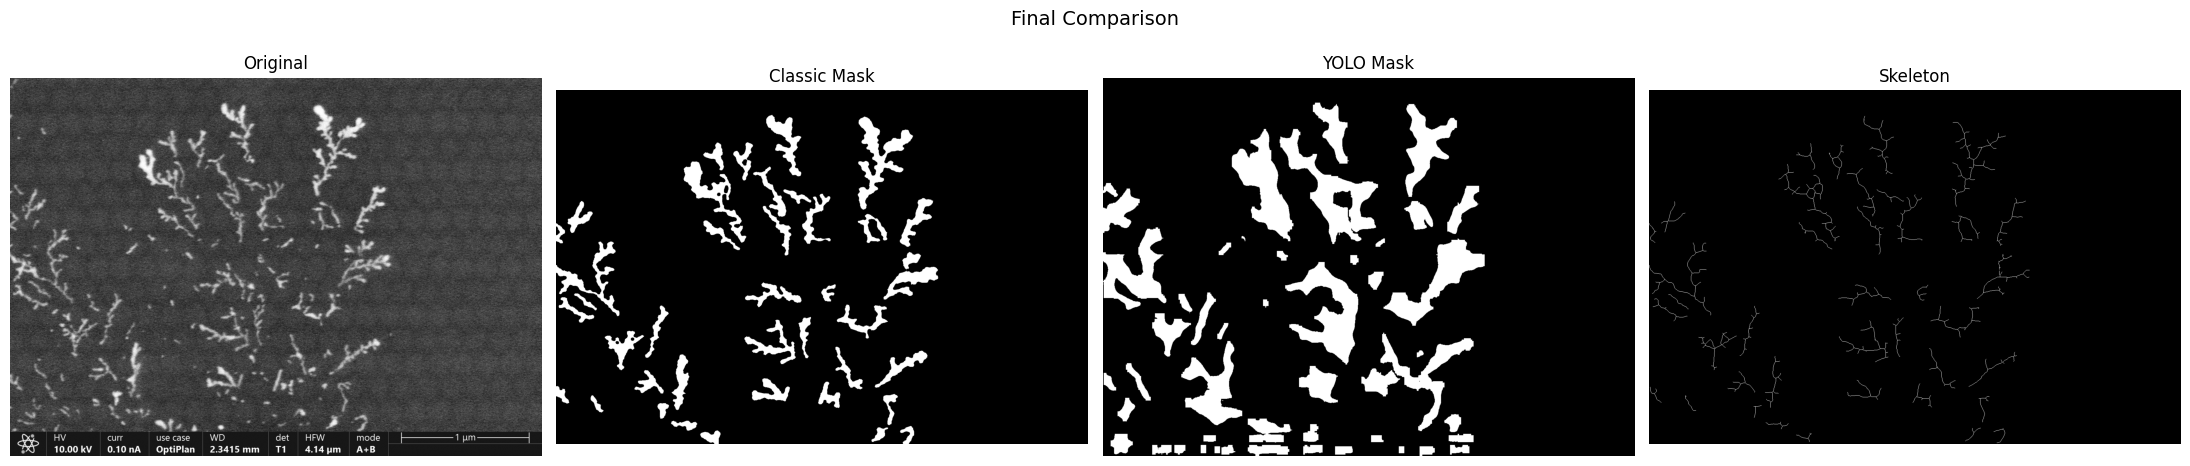

Saved final comparison to: /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/outputs/visuals/demo_comparison.png


In [8]:
comparison_out = Path('../outputs/visuals/demo_comparison.png')
comparison_out.parent.mkdir(parents=True, exist_ok=True)

classic_mask_rgb = cv2.cvtColor(post_mask, cv2.COLOR_GRAY2RGB)
yolo_mask_rgb = cv2.cvtColor(yolo_mask, cv2.COLOR_GRAY2RGB)
skeleton_rgb = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2RGB)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
panels = [
    (raw_image, 'Original', 'gray'),
    (classic_mask_rgb, 'Classic Mask', None),
    (yolo_mask_rgb, 'YOLO Mask', None),
    (skeleton_rgb, 'Skeleton', None),
]

for ax, (img, title, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

fig.suptitle('Final Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(comparison_out, bbox_inches='tight', dpi=150)
plt.show()

print(f"Saved final comparison to: {comparison_out.resolve()}")

**Summary**

| Pipeline | Visual Observation |
| --- | --- |
| Classic CV | Easier to explain step by step and produces a clean skeleton, but it is sensitive to thresholding and mask cleanup choices. |
| YOLO Tiled | Usually captures more complete dendrite regions with less manual tuning, but it depends on trained weights and behaves like a black box during the live demo. |
